# 05 — Intégration Ollama : Explications LLM des Fraudes Détectées

**Objectif :** Générer des explications en langage naturel pour les transactions
détectées comme frauduleuses par l'AutoEncoder (NB04).

**Pipeline :**
1. Charger les scores de reconstruction de l'AutoEncoder
2. Identifier les transactions frauduleuses (score > seuil)
3. Calculer l'erreur par feature pour chaque transaction
4. Envoyer un prompt structuré à Ollama
5. Parser et sauvegarder les explications JSON
6. Analyse et visualisation des explications

**Prérequis :**
```bash
# Installer et démarrer Ollama
# 1. Télécharger Ollama : https://ollama.com/download
# 2. Dans un terminal :
ollama pull llama3
ollama serve
```

In [1]:
from pathlib import Path
import sys, json, time, warnings
import yaml
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Chemins ───────────────────────────────────────────────────────────────────
project_root = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

CONFIG_DIR = project_root / 'config'
CONFIG_PATH = CONFIG_DIR / 'config.yaml'
OLLAMA_CONFIG_PATH = CONFIG_DIR / 'ollama_config.yaml'


def load_yaml_config(path):
    with open(path, encoding='utf-8') as f:
        return yaml.safe_load(f) or {}


project_config = load_yaml_config(CONFIG_PATH)
ollama_config = load_yaml_config(OLLAMA_CONFIG_PATH)

data_config = project_config.get('data', {})
output_config = project_config.get('output', {})
ollama_server_config = ollama_config.get('server', {})
ollama_model_config = ollama_config.get('model', {})
ollama_generation_config = ollama_config.get('generation', {})
ollama_pipeline_config = ollama_config.get('pipeline', {})
ollama_output_config = ollama_config.get('output', {})

PROCESSED_DIR = project_root / data_config.get('processed_path', 'data/processed/')
MODELS_DIR    = project_root / output_config.get('models_dir', 'outputs/models/')
REPORTS_DIR   = project_root / output_config.get('reports_dir', 'outputs/reports/')
FIGURES_DIR   = project_root / output_config.get('figures_dir', 'outputs/figures/')

EXPLANATIONS_PATH = Path(ollama_output_config.get('explanations_file', REPORTS_DIR / 'explanations.json'))
OLLAMA_SUMMARY_PATH = Path(ollama_output_config.get('summary_file', REPORTS_DIR / 'ollama_summary.json'))


OLLAMA_MODEL = 'llama3'  # mistral plus rapide que llama3 sur CPU
OLLAMA_BASE_URL = ollama_server_config.get('base_url', 'http://localhost:11434')
OLLAMA_TIMEOUT = 90  # timeout augmenté pour mistral
OLLAMA_TEMPERATURE = float(ollama_generation_config.get('temperature', 0.2)) #0.1
OLLAMA_MAX_TOKENS = 200  # tokens réduits pour aller plus vite
OLLAMA_TOP_P = float(ollama_generation_config.get('top_p', 0.9))
OLLAMA_TOP_K_FEATURES = int(ollama_pipeline_config.get('top_k_features', 3))
OLLAMA_MAX_EXPLAIN = 5   # limiter à 5 pour le test (éviter longue attente)
OLLAMA_BATCH_VERBOSE = bool(ollama_pipeline_config.get('batch_verbose', True))

print(f'Project root        : {project_root}')
print(f'Processed dir       : {PROCESSED_DIR}')
print(f'Models dir          : {MODELS_DIR}')
print(f'Reports dir         : {REPORTS_DIR}')
print(f'Figures dir         : {FIGURES_DIR}')
print(f'Ollama config file   : {OLLAMA_CONFIG_PATH}')
print(f'Ollama model        : {OLLAMA_MODEL}')
print(f'Ollama base URL     : {OLLAMA_BASE_URL}')
print(f'Ollama top-k feats  : {OLLAMA_TOP_K_FEATURES}')

Project root        : C:\Users\lenovo\Desktop\anomaly_detection_project
Processed dir       : C:\Users\lenovo\Desktop\anomaly_detection_project\data\processed
Models dir          : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\models
Reports dir         : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports
Figures dir         : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\figures
Ollama config file   : C:\Users\lenovo\Desktop\anomaly_detection_project\config\ollama_config.yaml
Ollama model        : llama3
Ollama base URL     : http://localhost:11434
Ollama top-k feats  : 3


## 1 — Constantes et Références

In [2]:
RANDOM_STATE = 42

# ── Références NB04 (à charger depuis le rapport) ────────────────────────────
with open(REPORTS_DIR / 'autoencoder_report.json', encoding='utf-8') as f:
    ae_report = json.load(f)

threshold_report = ae_report.get('threshold', {})
AE_THRESHOLD = ae_report.get('threshold_optimal', threshold_report.get('optimal'))
if AE_THRESHOLD is None:
    raise KeyError("Seuil AE introuvable dans autoencoder_report.json (attendu: 'threshold.optimal' ou 'threshold_optimal')")
AE_RECALL_TEST  = ae_report['test_metrics']['recall']
AE_F1_TEST      = ae_report['test_metrics']['f1']

# ── Références NB03 (meilleur modèle ML) ────────────────────────────────────
with open(REPORTS_DIR / 'baseline_report.json', encoding='utf-8') as f:
    baseline_report = json.load(f)

rf_report = next((model for model in baseline_report.get('models', []) if model.get('name') == 'RF_smote'), None)
if rf_report is None:
    raise KeyError("Modèle RF_smote introuvable dans baseline_report.json")

RF_RECALL = rf_report['test_metrics']['recall']
RF_F1     = rf_report['test_metrics']['f1']

print('Références chargées depuis les rapports :')
print(f'  AE seuil optimal : {AE_THRESHOLD:.6f}')
print(f'  AE Recall test   : {AE_RECALL_TEST:.4f}')
print(f'  AE F1 test       : {AE_F1_TEST:.4f}')
print(f'  RF_smote Recall  : {RF_RECALL:.4f}')
print(f'  RF_smote F1      : {RF_F1:.4f}')

Références chargées depuis les rapports :
  AE seuil optimal : 1.486097
  AE Recall test   : 0.3333
  AE F1 test       : 0.4127
  RF_smote Recall  : 0.7949
  RF_smote F1      : 0.8052


## 2 — Chargement des modules src/

In [3]:
import importlib

modules_to_check = [
    'src.models.autoencoder',
    'src.ollama_integration.ollama_helper',
    'src.utils.evaluator',
]

all_ok = True
for mod in modules_to_check:
    try:
        importlib.import_module(mod)
        print(f'  ✅ {mod}')
    except Exception as e:
        print(f'  ❌ {mod} → {e}')
        all_ok = False

assert all_ok, 'Certains modules src/ sont manquants ou cassés.'

from src.models.autoencoder              import FraudAutoEncoder
from src.ollama_integration.ollama_helper import OllamaHelper
from src.utils.evaluator                 import compute_fraud_metrics

print('\n✅ Modules src chargés.')

  ✅ src.models.autoencoder
  ✅ src.ollama_integration.ollama_helper
  ✅ src.utils.evaluator

✅ Modules src chargés.


## 3 — Chargement des données et artefacts

In [4]:
# ── Features ──────────────────────────────────────────────────────────────────
with open(MODELS_DIR / 'features.json', encoding='utf-8') as f:
    meta = json.load(f)

FEATURE_COLS = meta.get('feature_cols') or meta.get('all_features')
if FEATURE_COLS is None:
    raise KeyError("Impossible de trouver la liste des features dans features.json (attendu: 'feature_cols' ou 'all_features')")
TARGET       = meta.get('target', 'isFraud')

print(f'Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'Target : {TARGET}')

Features (14) : ['step', 'hour', 'day', 'week', 'high_risk_hour', 'is_transfer_or_cashout', 'balance_diff_orig', 'dest_zero_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'log_amount']
Target : isFraud


In [5]:
# ── Chargement X_test et y_test ───────────────────────────────────────────────
def load_split(prefix):
    csv_X = PROCESSED_DIR / f'X_{prefix}.csv'
    csv_y = PROCESSED_DIR / f'y_{prefix}.csv'
    if csv_X.exists():
        X = pd.read_csv(csv_X)
        y = pd.read_csv(csv_y).iloc[:, 0]
    else:
        X = pd.DataFrame(
            np.load(PROCESSED_DIR / f'X_{prefix}.npy', allow_pickle=True).astype(float),
            columns=FEATURE_COLS
        )
        y = pd.Series(
            np.load(PROCESSED_DIR / f'y_{prefix}.npy', allow_pickle=True).astype(int),
            name=TARGET
        )
    X = X[FEATURE_COLS].astype(float)
    y = y.astype(int)
    return X, y

X_test, y_test = load_split('test')
X_val,  y_val  = load_split('val')

print(f'X_test : {X_test.shape}  fraudes={int(y_test.sum())}')
print(f'X_val  : {X_val.shape}   fraudes={int(y_val.sum())}')

X_test : (30001, 14)  fraudes=39
X_val  : (30000, 14)   fraudes=38


In [6]:
# ── Chargement AutoEncoder ────────────────────────────────────────────────────
ae = FraudAutoEncoder.load(MODELS_DIR / 'autoencoder')
print(f'AutoEncoder chargé')
print(f'  Seuil optimal : {ae.threshold:.6f}')
print(f'  Architecture  : {ae}')

# ── Chargement scores de reconstruction (pré-calculés dans NB04) ─────────────
#ae_scores_test = np.load(MODELS_DIR / 'ae_scores_test.npy')
def safe_load(path):
    if not path.exists():
        raise FileNotFoundError(f"Fichier manquant : {path}")
    return np.load(path)

ae_scores_test = safe_load(MODELS_DIR / 'ae_scores_test.npy')
ae_scores_val  = np.load(MODELS_DIR / 'ae_scores_val.npy')

print(f'\nScores chargés :')
print(f'  ae_scores_test : {ae_scores_test.shape}  min={ae_scores_test.min():.4f}  max={ae_scores_test.max():.4f}')
print(f'  ae_scores_val  : {ae_scores_val.shape}   min={ae_scores_val.min():.4f}  max={ae_scores_val.max():.4f}')

AutoEncoder chargé
  Seuil optimal : 1.486097
  Architecture  : <src.models.autoencoder.FraudAutoEncoder object at 0x000002257E8F34D0>

Scores chargés :
  ae_scores_test : (30001,)  min=0.0064  max=320.2985
  ae_scores_val  : (30000,)   min=0.0064  max=320.7873


## 4 — Identification des transactions frauduleuses détectées

In [7]:
threshold = AE_THRESHOLD

# Prédictions AE sur test
y_pred_ae = (ae_scores_test >= threshold).astype(int)

# Transactions flaggées comme fraudes par l'AE
flagged_mask   = y_pred_ae == 1
flagged_idx    = np.where(flagged_mask)[0]

# Vrais positifs (TP) et faux positifs (FP)
y_test_arr     = np.asarray(y_test)
tp_mask        = flagged_mask & (y_test_arr == 1)
fp_mask        = flagged_mask & (y_test_arr == 0)
fn_mask        = (~flagged_mask) & (y_test_arr == 1)

n_flagged = flagged_mask.sum()
n_tp      = tp_mask.sum()
n_fp      = fp_mask.sum()
n_fn      = fn_mask.sum()

print(f'Seuil AE       : {threshold:.6f}')
print(f'Transactions flaggées : {n_flagged}')
print(f'  TP (vraies fraudes détectées) : {n_tp}')
print(f'  FP (fausses alertes)          : {n_fp}')
print(f'  FN (fraudes manquées)         : {n_fn}')
print(f'  Recall : {n_tp / int(y_test.sum()):.4f}')

Seuil AE       : 1.486097
Transactions flaggées : 24
  TP (vraies fraudes détectées) : 13
  FP (fausses alertes)          : 11
  FN (fraudes manquées)         : 26
  Recall : 0.3333


## 5 — Calcul des erreurs de reconstruction par feature

In [8]:
# Reconstruction de toutes les transactions du test set
print('Calcul des erreurs de reconstruction par feature...')
t0 = time.time()

X_test_arr  = X_test.values.astype(np.float32)
X_test_rec  = ae.model.predict(X_test_arr, batch_size=1024, verbose=0)

# Erreur absolue par feature : shape (N, 14)
feature_errors_test = np.abs(X_test_arr - X_test_rec)

print(f'✅ Erreurs calculées en {time.time()-t0:.1f}s')
print(f'   Shape feature_errors_test : {feature_errors_test.shape}')

# Vérification : top-3 features pour la transaction avec le score le plus élevé
worst_idx   = np.argmax(ae_scores_test)
worst_errs  = feature_errors_test[worst_idx]
top3_idx    = np.argsort(worst_errs)[::-1][:3]

print(f'\nTransaction la plus anormale (idx={worst_idx}, score={ae_scores_test[worst_idx]:.4f}) :')
for i, fi in enumerate(top3_idx, 1):
    print(f'  {i}. {FEATURE_COLS[fi]:30s} erreur={worst_errs[fi]:.4f}')

Calcul des erreurs de reconstruction par feature...


✅ Erreurs calculées en 1.6s
   Shape feature_errors_test : (30001, 14)

Transaction la plus anormale (idx=29340, score=320.2985) :
  1. balance_diff_orig              erreur=62.7984
  2. hour                           erreur=21.5341
  3. log_amount                     erreur=5.0008


## 6 — Vérification Ollama

In [9]:
# Initialisation du client Ollama
helper = OllamaHelper(
    model         = OLLAMA_MODEL,
    base_url      = OLLAMA_BASE_URL,
    timeout       = OLLAMA_TIMEOUT,
    temperature   = OLLAMA_TEMPERATURE,
    max_tokens    = OLLAMA_MAX_TOKENS,
    feature_names = FEATURE_COLS,
)

ollama_ok = helper.is_available()
print(f'Ollama disponible : {ollama_ok}')

if ollama_ok:
    models = helper.list_models()
    print(f'Modèles disponibles : {models}')
    if OLLAMA_MODEL not in str(models) and f'{OLLAMA_MODEL}:latest' not in str(models):
        print(f'⚠️  {OLLAMA_MODEL} non trouvé. Lance : ollama pull {OLLAMA_MODEL}')
        print('   Fallback rule-based activé automatiquement.')
else:
    print('⚠️  Ollama non démarré.')
    print('   → Mode fallback rule-based activé (explications basées sur les règles).')
    print('   → Pour activer le LLM : lancer ollama serve dans un terminal.')

Ollama disponible : False
⚠️  Ollama non démarré.
   → Mode fallback rule-based activé (explications basées sur les règles).
   → Pour activer le LLM : lancer ollama serve dans un terminal.


## 7 — Test sur une seule transaction

In [10]:
# ── Prendre la transaction TP avec le score le plus élevé ────────────────────
tp_indices  = np.where(tp_mask)[0]
best_tp_idx = tp_indices[np.argmax(ae_scores_test[tp_indices])]

transaction_dict = dict(zip(FEATURE_COLS, X_test_arr[best_tp_idx].tolist()))
feat_errors      = feature_errors_test[best_tp_idx]
score            = float(ae_scores_test[best_tp_idx])

print(f'Transaction test (TP, score={score:.4f}, idx={best_tp_idx}) :')
for feat, val in transaction_dict.items():
    print(f'  {feat:30s} = {val:.4f}')

print(f'\nTop-3 features les plus anormales :')
top3 = np.argsort(feat_errors)[::-1][:3]
for i, fi in enumerate(top3, 1):
    print(f'  {i}. {FEATURE_COLS[fi]:30s} erreur={feat_errors[fi]:.4f}')

Transaction test (TP, score=320.2985, idx=29340) :
  step                           = 3.4143
  hour                           = -1.2305
  day                            = 3.4564
  week                           = 3.4727
  high_risk_hour                 = 0.0000
  is_transfer_or_cashout         = 1.0000
  balance_diff_orig              = 66.0686
  dest_zero_balance              = 1.0000
  type_CASH_IN                   = 0.0000
  type_CASH_OUT                  = 0.0000
  type_DEBIT                     = 0.0000
  type_PAYMENT                   = 0.0000
  type_TRANSFER                  = 1.0000
  log_amount                     = 2.9061

Top-3 features les plus anormales :
  1. balance_diff_orig              erreur=62.7984
  2. hour                           erreur=21.5341
  3. log_amount                     erreur=5.0008


In [11]:
# ── Génération de l'explication ───────────────────────────────────────────────
print('Génération de l\'explication...\n')
t0 = time.time()

explanation = helper.explain_fraud(
    transaction     = transaction_dict,
    feature_errors  = feat_errors,
    ae_score        = score,
    threshold       = threshold,
    top_k           = OLLAMA_TOP_K_FEATURES,
)

print(f'Durée : {time.time()-t0:.1f}s  |  Status : {explanation["status"]}')
print(f'Modèle utilisé : {explanation["model"]}')
print()
print(json.dumps(explanation, ensure_ascii=False, indent=2))

Génération de l'explication...

Durée : 0.0s  |  Status : fallback_no_llm
Modèle utilisé : rule_based

{
  "risk_level": "CRITIQUE",
  "ae_score": 320.298523,
  "threshold": 1.486097,
  "resume": "Transaction suspecte avec score d'anomalie 320.2985 (seuil : 1.4861). Anomalies détectées sur : balance_diff_orig, hour, log_amount.",
  "raisons": [
    "Le solde du compte émetteur a été fortement diminué, signe potentiel de vidage de compte.",
    "L'heure de la transaction correspond à une période d'activité inhabituelle.",
    "Le montant de la transaction est anormalement élevé par rapport aux transactions normales."
  ],
  "actions_recommandees": [
    "Vérifier manuellement les détails de la transaction.",
    "Contacter le titulaire du compte pour confirmation.",
    "Bloquer temporairement le compte si plusieurs transactions similaires sont détectées."
  ],
  "confiance": "MOYENNE",
  "top_features": [
    {
      "feature": "balance_diff_orig",
      "error": 62.798393,
      "valu

## 8 — Génération batch sur toutes les fraudes détectées

In [12]:
# Préparer la liste des transactions flaggées
flagged_transactions = [
    dict(zip(FEATURE_COLS, X_test_arr[i].tolist()))
    for i in flagged_idx
]
flagged_errors = feature_errors_test[flagged_idx]
flagged_scores = ae_scores_test[flagged_idx]

print(f'Transactions à expliquer : {len(flagged_transactions)}')
print(f'  TP : {tp_mask[flagged_idx].sum()}')
print(f'  FP : {fp_mask[flagged_idx].sum()}')
print()

# Génération batch
print('Génération des explications...')
explanations = helper.explain_batch(
    transactions         = flagged_transactions,
    feature_errors_batch = flagged_errors,
    ae_scores            = flagged_scores,
    threshold            = threshold,
    top_k                = OLLAMA_TOP_K_FEATURES,
    verbose              = OLLAMA_BATCH_VERBOSE,
    max_explain          = min(OLLAMA_MAX_EXPLAIN, len(flagged_transactions)),
)

Transactions à expliquer : 24
  TP : 13
  FP : 11

Génération des explications...
  [  1/5] Transaction idx=22 | score=320.2985 

| CRITIQUE | fallback_no_llm (0.0s)
  [  2/5] Transaction idx=5 | score=269.3647 

| CRITIQUE | fallback_no_llm (0.0s)
  [  3/5] Transaction idx=18 | score=67.9010 

| CRITIQUE | fallback_no_llm (0.0s)
  [  4/5] Transaction idx=3 | score=51.8941 

| CRITIQUE | fallback_no_llm (0.0s)
  [  5/5] Transaction idx=2 | score=11.3295 

| CRITIQUE | fallback_no_llm (0.0s)

  Total : 5 explications en 0.0s
  ✅ LLM : 0  |  ⚠ Fallback : 5  |  ❌ Erreurs : 0


## 9 — Analyse des explications générées

In [13]:
# ── Statistiques des explications ─────────────────────────────────────────────
status_counts    = {}
risk_counts      = {}
confiance_counts = {}
feature_mentions = {f: 0 for f in FEATURE_COLS}

for expl in explanations:
    status_counts[expl.get('status','?')] = status_counts.get(expl.get('status','?'), 0) + 1
    risk_counts[expl.get('risk_level','?')] = risk_counts.get(expl.get('risk_level','?'), 0) + 1
    confiance_counts[expl.get('confiance','?')] = confiance_counts.get(expl.get('confiance','?'), 0) + 1
    for tf in expl.get('top_features', []):
        feat = tf.get('feature','')
        if feat in feature_mentions:
            feature_mentions[feat] += 1

print(f'=== Statistiques des {len(explanations)} explications ===')
print(f'\nStatut LLM :')
for k, v in status_counts.items():
    print(f'  {k:<30s} : {v}')

print(f'\nNiveau de risque :')
for k, v in sorted(risk_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<15s} : {v}')

print(f'\nConfiance :')
for k, v in sorted(confiance_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<15s} : {v}')

print(f'\nTop features citées :')
for feat, count in sorted(feature_mentions.items(), key=lambda x: -x[1])[:7]:
    if count > 0:
        print(f'  {feat:<35s} : {count}x')

=== Statistiques des 5 explications ===

Statut LLM :
  fallback_no_llm                : 5

Niveau de risque :
  CRITIQUE        : 5

Confiance :
  MOYENNE         : 5

Top features citées :
  hour                                : 5x
  balance_diff_orig                   : 5x
  log_amount                          : 5x


## 10 — Visualisations

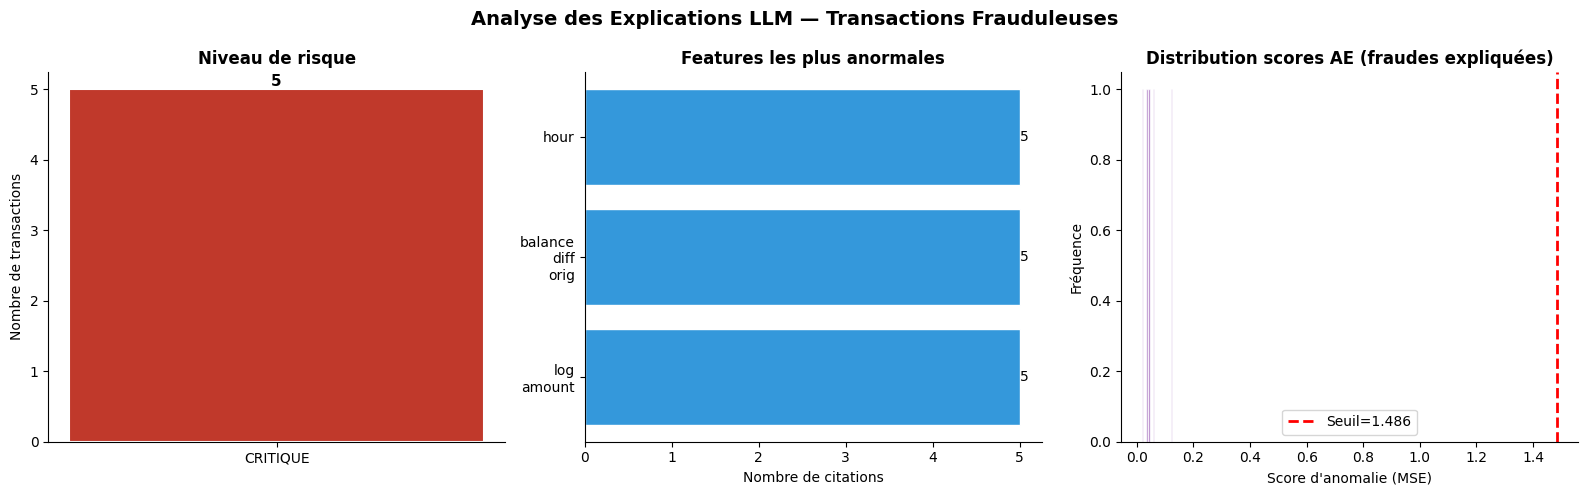

Figure sauvegardée : 24_ollama_analysis.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analyse des Explications LLM — Transactions Frauduleuses', fontsize=14, fontweight='bold')

COLORS = {'CRITIQUE': '#C0392B', 'ÉLEVÉ': '#E67E22', 'MODÉRÉ': '#F1C40F',
          'HAUTE': '#27AE60', 'MOYENNE': '#3498DB', 'FAIBLE': '#95A5A6'}

# ── Graphe 1 : Répartition des niveaux de risque ──────────────────────────────
ax = axes[0]
risk_labels = [k for k in risk_counts if k != '?']
risk_values = [risk_counts[k] for k in risk_labels]
colors_risk = [COLORS.get(k, '#BDC3C7') for k in risk_labels]
bars = ax.bar(risk_labels, risk_values, color=colors_risk, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%d', fontsize=11, fontweight='bold')
ax.set_title('Niveau de risque', fontweight='bold')
ax.set_ylabel('Nombre de transactions')
ax.set_xlabel('')
ax.spines[['top','right']].set_visible(False)

# ── Graphe 2 : Top features citées ────────────────────────────────────────────
ax = axes[1]
top_feats = sorted(
    [(f, c) for f, c in feature_mentions.items() if c > 0],
    key=lambda x: -x[1]
)[:8]
feat_names   = [f.replace('_', '\n') for f, _ in top_feats]
feat_counts  = [c for _, c in top_feats]
bars2 = ax.barh(feat_names[::-1], feat_counts[::-1], color='#3498DB', edgecolor='white')
ax.bar_label(bars2, fmt='%d', fontsize=10)
ax.set_title('Features les plus anormales', fontweight='bold')
ax.set_xlabel('Nombre de citations')
ax.spines[['top','right']].set_visible(False)

# ── Graphe 3 : Distribution des scores AE pour les transactions expliquées ────
ax = axes[2]
explained_idx = [e['transaction_idx'] for e in explanations if 'transaction_idx' in e]
explained_scores = ae_scores_test[explained_idx] if explained_idx else flagged_scores
ax.hist(explained_scores, bins=20, color='#8E44AD', alpha=0.8, edgecolor='white')
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil={threshold:.3f}')
ax.set_title('Distribution scores AE (fraudes expliquées)', fontweight='bold')
ax.set_xlabel('Score d\'anomalie (MSE)')
ax.set_ylabel('Fréquence') 
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '24_ollama_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 24_ollama_analysis.png')

In [15]:
print("Nombre total explanations :", len(explanations))

from collections import Counter
print("Statuses :", Counter(e.get("status") for e in explanations))

Nombre total explanations : 5
Statuses : Counter({'fallback_no_llm': 5})


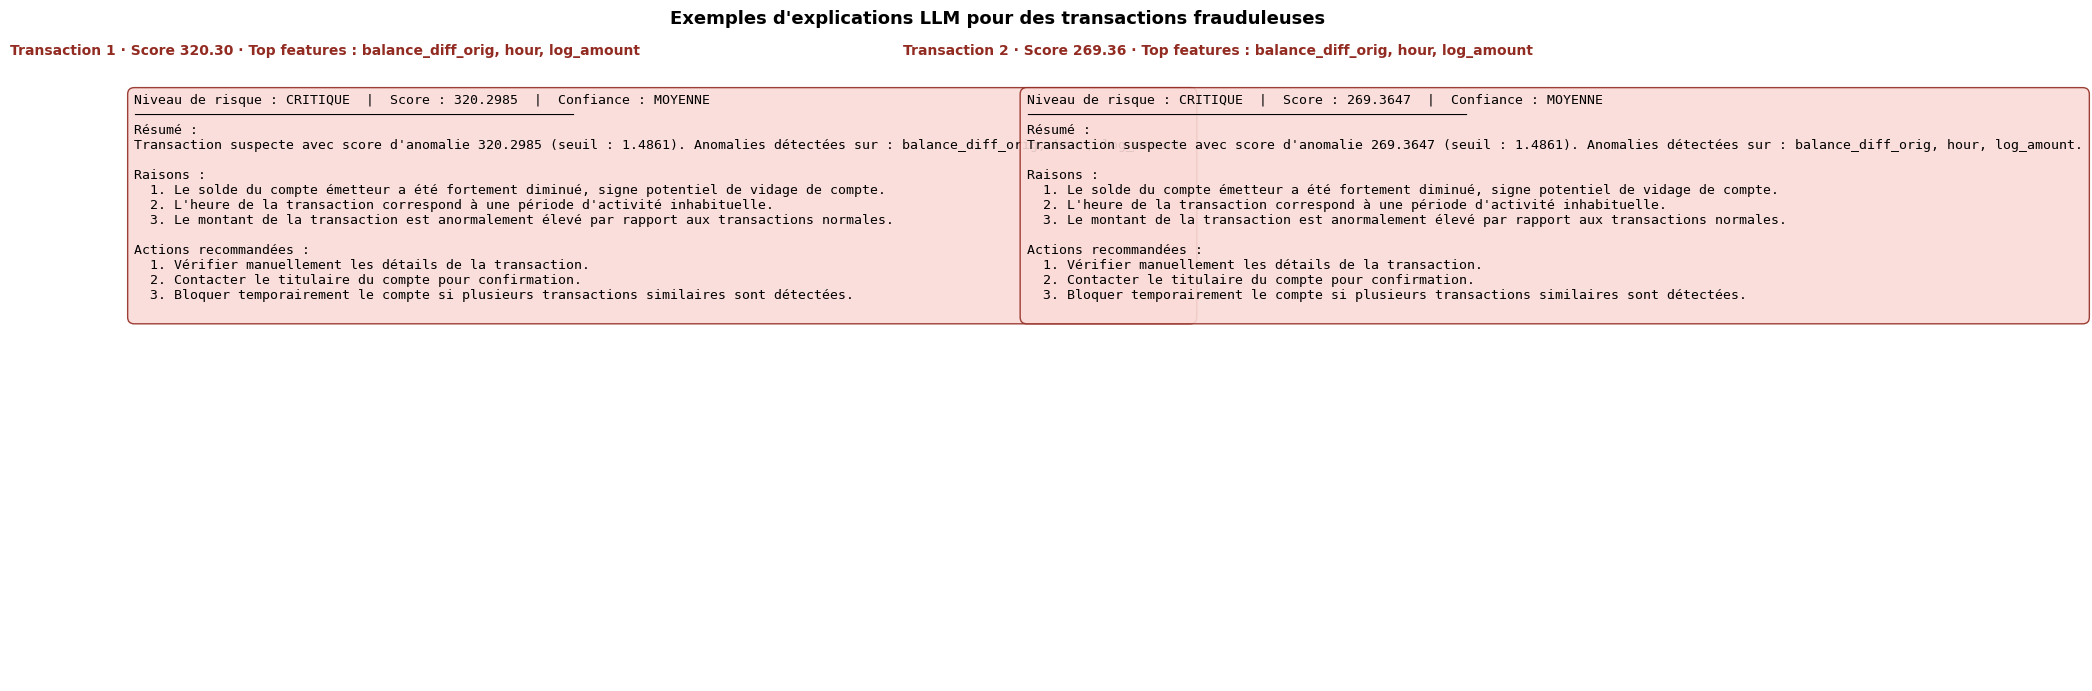

Figure sauvegardée : 25_explanation_examples.png


In [16]:
# ── Figure 25 : Exemples d'explications ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Exemples d\'explications LLM pour des transactions frauduleuses', fontsize=13, fontweight='bold')

# Prendre 2 exemples : meilleur TP (score le plus élevé) et pire TP (score le plus bas)
# Accepter toutes les explications (ok, fallback, timeout — toutes ont les données)
ok_expls = [e for e in explanations if e.get('raisons')]  # filtre : données présentes

for ax_idx, (ax, expl) in enumerate(zip(axes, ok_expls[:2])):
    ax.axis('off')
    risk   = expl.get('risk_level', 'N/A')
    score  = expl.get('ae_score', 0)   
    resume = expl.get('resume', 'N/A')
    raisons = expl.get('raisons', [])
    actions = expl.get('actions_recommandees', [])
    conf   = expl.get('confiance', 'N/A')

    color  = {'CRITIQUE': '#FADBD8', 'ÉLEVÉ': '#FDEBD0', 'MODÉRÉ': '#FEF9E7'}.get(risk, '#EBF5FB')
    t_color = {'CRITIQUE': '#922B21', 'ÉLEVÉ': '#784212', 'MODÉRÉ': '#7D6608'}.get(risk, '#1A5276')

    txt  = f'Niveau de risque : {risk}  |  Score : {score:.4f}  |  Confiance : {conf}\n'
    txt += '─' * 55 + '\n'
    txt += f'Résumé :\n{resume}\n\n'
    txt += 'Raisons :\n'
    for i, r in enumerate(raisons, 1):
        txt += f'  {i}. {r}\n'
    txt += '\nActions recommandées :\n'
    for i, a in enumerate(actions, 1):
        txt += f'  {i}. {a}\n'

    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            fontsize=9.5, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.9, edgecolor=t_color))
    ax.set_title(f'Transaction {ax_idx+1} · Score {expl.get("ae_score",0):.2f} · Top features : ' +
                 ', '.join(tf["feature"] for tf in expl.get("top_features",[])[:3]),
                 fontsize=10, color=t_color, fontweight='bold')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '25_explanation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 25_explanation_examples.png')

## 11 — Sauvegarde

In [17]:
# ── explanations.json ─────────────────────────────────────────────────────────
def resolve_output_path(path_like):
    path = Path(path_like)
    if not path.is_absolute():
        path = (project_root / path).resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    return path

output_path = resolve_output_path(EXPLANATIONS_PATH)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(explanations, f, ensure_ascii=False, indent=2)

size_kb = output_path.stat().st_size // 1024
print(f'✅ explanations.json sauvegardé ({size_kb} Ko)')
print(f'   {len(explanations)} explications')

# ── ollama_summary.json ───────────────────────────────────────────────────────
summary = {
    'n_flagged_total'    : int(n_flagged),
    'n_explained'        : len(explanations),
    'n_tp'               : int(n_tp),
    'n_fp'               : int(n_fp),
    'ae_threshold'       : float(threshold),
    'ae_recall'          : float(AE_RECALL_TEST),
    'ae_f1'              : float(AE_F1_TEST),
    'rf_smote_recall'    : float(RF_RECALL),
    'rf_smote_f1'        : float(RF_F1),
    'risk_distribution'  : risk_counts,
    'confiance_distribution': confiance_counts,
    'status_distribution': status_counts,
    'top_features_cited' : [
        {'feature': f, 'count': c}
        for f, c in sorted(feature_mentions.items(), key=lambda x: -x[1])
        if c > 0
    ],
    'llm_model'          : helper.model,
    'llm_available'      : helper.is_available(),
}

summary_path = resolve_output_path(OLLAMA_SUMMARY_PATH)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('✅ ollama_summary.json sauvegardé')
print(f'   {output_path}')
print(f'   {summary_path}')

✅ explanations.json sauvegardé (6 Ko)
   5 explications
✅ ollama_summary.json sauvegardé
   C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\explanations.json
   C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\ollama_summary.json


## 12 — Synthèse finale

In [18]:
print('=' * 60)
print('  SYNTHÈSE — NB05 Ollama LLM')
print('=' * 60)
print()
print(f'  AutoEncoder (NB04) :')
print(f'    Recall        : {AE_RECALL_TEST:.4f}')
print(f'    F1-Score      : {AE_F1_TEST:.4f}')
print(f'    Seuil         : {threshold:.6f}')
print()
print(f'  Transactions flaggées  : {n_flagged}')
print(f'  Explications générées  : {len(explanations)}')
print(f'  Mode LLM               : {"Ollama " + helper.model if helper.is_available() else "Fallback rule-based"}')
print()
print(f'  Répartition risque :')
for k, v in sorted(risk_counts.items(), key=lambda x: -x[1]):
    if k != '?':
        print(f'    {k:<12s} : {v}')
print()
print(f'  Feature #1 la plus citée : {top_feats[0][0] if top_feats else "N/A"}')
print()
print(f'  Artefacts sauvegardés :')
print(f'    outputs/reports/explanations.json')
print(f'    outputs/reports/ollama_summary.json')
print(f'    outputs/figures/24_ollama_analysis.png')
print(f'    outputs/figures/25_explanation_examples.png')
print('=' * 60)
print()
print('✅ NB05 terminé. Pipeline complet :')
print('   NB01 EDA → NB02 Préparation → NB03 Baselines ML')
print('   → NB04 AutoEncoder → NB05 Explications LLM')

  SYNTHÈSE — NB05 Ollama LLM

  AutoEncoder (NB04) :
    Recall        : 0.3333
    F1-Score      : 0.4127
    Seuil         : 1.486097

  Transactions flaggées  : 24
  Explications générées  : 5
  Mode LLM               : Fallback rule-based

  Répartition risque :
    CRITIQUE     : 5

  Feature #1 la plus citée : hour

  Artefacts sauvegardés :
    outputs/reports/explanations.json
    outputs/reports/ollama_summary.json
    outputs/figures/24_ollama_analysis.png
    outputs/figures/25_explanation_examples.png

✅ NB05 terminé. Pipeline complet :
   NB01 EDA → NB02 Préparation → NB03 Baselines ML
   → NB04 AutoEncoder → NB05 Explications LLM
